# Week 2: Decision Trees and Random Forests - Bias-Variance Tradeoff

This notebook explores the performance of **Decision Tree Regressors** and **Random Forest Regressors** on a noisy non-linear dataset. We will study how changing hyperparameters affects bias and variance, and empirically demonstrate how ensembling (bagging) reduces model variance.

### Learning Objectives:
* Train and evaluate a Decision Tree Regressor.
* Train and evaluate a Random Forest Regressor.
* Explain bias, variance, and the bias–variance tradeoff in plain language.
* Empirically demonstrate, using code and plots, how ensembling (bagging) reduces variance.


## Dataset Generation
We will use a noisy sine wave function as our target:
$$y = \sin(1.5 \pi x) + \epsilon$$
We will generate 200 samples and split them into 70% training and 30% testing.


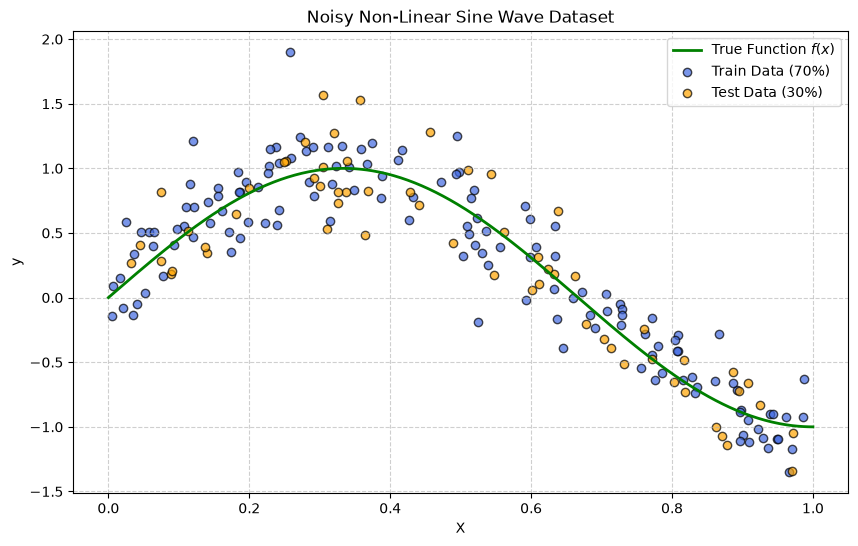

X_train shape: (140, 1), y_train shape: (140,)
X_test shape: (60, 1), y_test shape: (60,)


In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

np.random.seed(42)

def true_function(x):
    return np.sin(1.5 * np.pi * x)

n_samples = 200
X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.normal(0, 0.25, n_samples)
X = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Visualize the dataset
X_grid = np.linspace(0, 1, 500).reshape(-1, 1)
plt.figure(figsize=(10, 6))
plt.plot(X_grid, true_function(X_grid), label="True Function $f(x)$", color="green", lw=2)
plt.scatter(X_train, y_train, label="Train Data (70%)", color="royalblue", alpha=0.7, edgecolors='k')
plt.scatter(X_test, y_test, label="Test Data (30%)", color="orange", alpha=0.7, edgecolors='k')
plt.title("Noisy Non-Linear Sine Wave Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


## Part A — Decision Tree Regressor

We will now train Decision Tree Regressors and evaluate their performance.


In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# 1. Train a single DecisionTreeRegressor with max_depth=None (fully grown)
dt_fully_grown = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_fully_grown.fit(X_train, y_train)

# 2. Compute Train MSE and Test MSE
train_pred = dt_fully_grown.predict(X_train)
test_pred = dt_fully_grown.predict(X_test)

train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("Fully Grown Decision Tree (max_depth=None):")
print(f"  Train MSE: {train_mse:.6f}")
print(f"  Test MSE:  {test_mse:.6f}")


Fully Grown Decision Tree (max_depth=None):
  Train MSE: 0.000000
  Test MSE:  0.120518


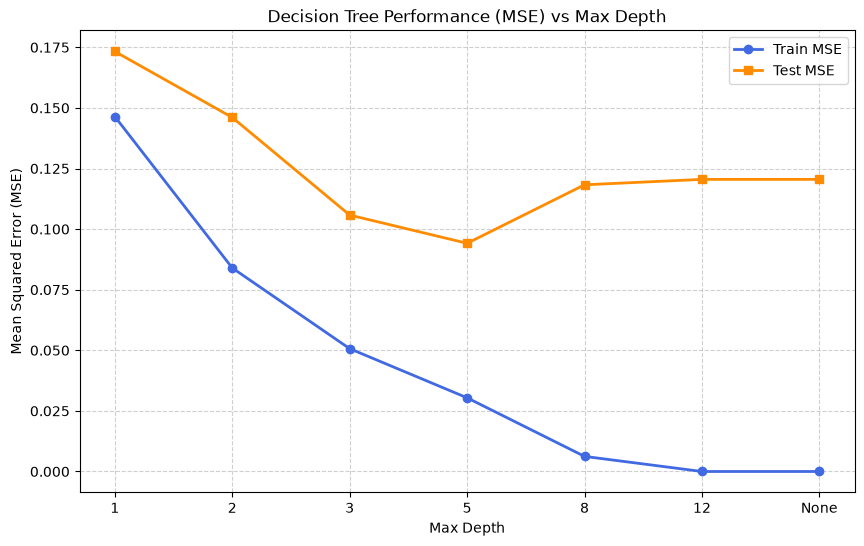

Max Depth    | Train MSE    | Test MSE    
------------------------------------------
1            | 0.146427     | 0.173274    
2            | 0.083966     | 0.146064    
3            | 0.050676     | 0.105790    
5            | 0.030398     | 0.094147    
8            | 0.006231     | 0.118279    
12           | 0.000000     | 0.120518    
None (Fully) | 0.000000     | 0.120518    


In [3]:
# 3. Repeat for max_depth = 1, 2, 3, 5, 8, 12, None. Plot Train MSE and Test MSE vs max_depth on the same chart.
max_depths = [1, 2, 3, 5, 8, 12, None]
train_mses = []
test_mses = []

for depth in max_depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_mses.append(mean_squared_error(y_train, dt.predict(X_train)))
    test_mses.append(mean_squared_error(y_test, dt.predict(X_test)))

# Plotting the results
plt.figure(figsize=(10, 6))
depth_labels = [str(d) for d in max_depths]
plt.plot(depth_labels, train_mses, label="Train MSE", marker='o', color='royalblue', lw=2)
plt.plot(depth_labels, test_mses, label="Test MSE", marker='s', color='darkorange', lw=2)
plt.xlabel("Max Depth")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Decision Tree Performance (MSE) vs Max Depth")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Print as a nice comparison table
print(f"{'Max Depth':<12} | {'Train MSE':<12} | {'Test MSE':<12}")
print("-" * 42)
for depth, tr, te in zip(max_depths, train_mses, test_mses):
    depth_str = str(depth) if depth is not None else "None (Fully)"
    print(f"{depth_str:<12} | {tr:<12.6f} | {te:<12.6f}")


### Written Answers (Part A)

#### 4. In your own words: At max_depth=1, is the model biased or high-variance? Why?
At `max_depth=1`, the model is **highly biased** (low variance). A tree with a depth of 1 (a "decision stump") makes only a single split, which divides the data into two regions and predicts a flat value for each. Since our true data is a curvy sine wave, a simple step function with only two levels is far too simple to capture that shape (underfitting), which leads to a high training and test error (high bias). However, it has low variance because minor changes in the training data won't shift the position of this single split very much.

#### 5. In your own words: At max_depth=None, what happens to Train MSE vs Test MSE? What does this indicate?
At `max_depth=None`, the **Train MSE drops to 0.0**, but the **Test MSE is much higher** (around 0.12). This gap indicates **overfitting** (high variance). Since there's no limit on the depth, the tree keeps splitting until every leaf has just one training sample. It basically memorizes the exact training points, including all the random noise. When we test it on new, unseen data, it performs poorly because the memorized noise doesn't apply to the test set, leading to a high Test MSE.


## Part B — Random Forest Regressor

We will now train Random Forest Regressors to see how ensembling affects model performance.


In [4]:
from sklearn.ensemble import RandomForestRegressor

# 6. Train a RandomForestRegressor with n_estimators=200, max_depth=None.
rf_model = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)

# 7. Compute Train MSE and Test MSE, and compare with the single fully-grown tree from Part A.
rf_train_mse = mean_squared_error(y_train, rf_model.predict(X_train))
rf_test_mse = mean_squared_error(y_test, rf_model.predict(X_test))

# Retrieve single fully grown tree MSEs from Part A
dt_fully_grown_train_mse = train_mses[-1]
dt_fully_grown_test_mse = test_mses[-1]

print("Comparison of Fully Grown Decision Tree vs Random Forest (200 trees):")
print(f"{'Model':<30} | {'Train MSE':<12} | {'Test MSE':<12}")
print("-" * 60)
print(f"{'Decision Tree (max_depth=None)':<30} | {dt_fully_grown_train_mse:<12.6f} | {dt_fully_grown_test_mse:<12.6f}")
print(f"{'Random Forest (n_estimators=200)':<30} | {rf_train_mse:<12.6f} | {rf_test_mse:<12.6f}")


Comparison of Fully Grown Decision Tree vs Random Forest (200 trees):
Model                          | Train MSE    | Test MSE    
------------------------------------------------------------
Decision Tree (max_depth=None) | 0.000000     | 0.120518    
Random Forest (n_estimators=200) | 0.010461     | 0.101234    


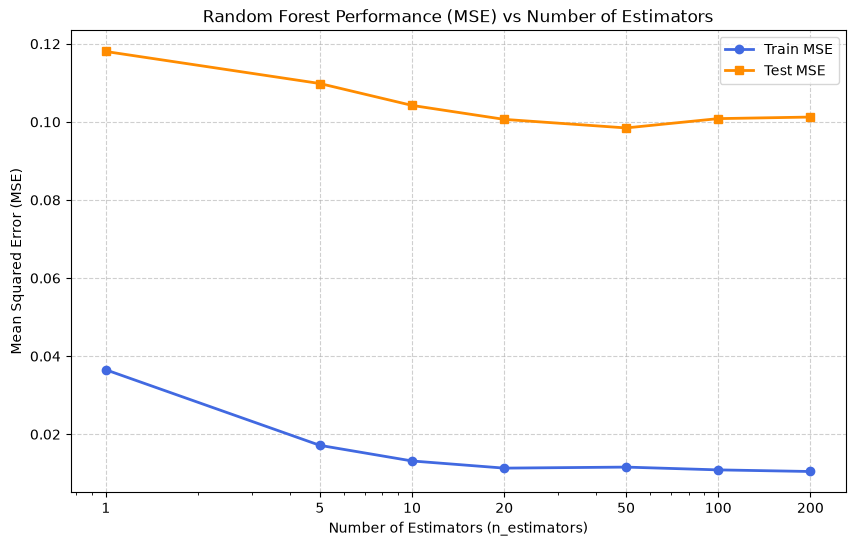

n_estimators | Train MSE    | Test MSE    
------------------------------------------
1            | 0.036509     | 0.118024    
5            | 0.017159     | 0.109823    
10           | 0.013159     | 0.104218    
20           | 0.011325     | 0.100641    
50           | 0.011588     | 0.098449    
100          | 0.010874     | 0.100834    
200          | 0.010461     | 0.101234    


In [5]:
# 8. Vary n_estimators = 1, 5, 10, 20, 50, 100, 200 and plot Train/Test MSE vs n_estimators.
n_estimators_list = [1, 5, 10, 20, 50, 100, 200]
rf_train_mses = []
rf_test_mses = []

for n_est in n_estimators_list:
    rf = RandomForestRegressor(n_estimators=n_est, max_depth=None, random_state=42)
    rf.fit(X_train, y_train)
    rf_train_mses.append(mean_squared_error(y_train, rf.predict(X_train)))
    rf_test_mses.append(mean_squared_error(y_test, rf.predict(X_test)))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, rf_train_mses, label="Train MSE", marker='o', color='royalblue', lw=2)
plt.plot(n_estimators_list, rf_test_mses, label="Test MSE", marker='s', color='darkorange', lw=2)
plt.xlabel("Number of Estimators (n_estimators)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Random Forest Performance (MSE) vs Number of Estimators")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.xscale('log')
plt.xticks(n_estimators_list, labels=[str(n) for n in n_estimators_list])
plt.show()

# Print as comparison table
print(f"{'n_estimators':<12} | {'Train MSE':<12} | {'Test MSE':<12}")
print("-" * 42)
for n_est, tr, te in zip(n_estimators_list, rf_train_mses, rf_test_mses):
    print(f"{n_est:<12} | {tr:<12.6f} | {te:<12.6f}")


### Written Answers (Part B)

#### 9. Why does Test MSE improve/plateau as `n_estimators` increases, while Train MSE stays roughly flat?
The **Train MSE stays flat and low** (around 0.01) because every single tree in the forest is fully grown (`max_depth=None`). Since each tree is trained on a bootstrap sample, it can fit that sample almost perfectly, keeping the individual tree's training error close to zero.

The **Test MSE improves and plateaus** because the Random Forest averages the predictions of all these trees. Since each tree is trained on a different bootstrap sample, their errors are mostly independent. When we average their outputs, the positive and negative errors cancel each other out, which reduces the overall variance and makes the predictions generalize better (lowering the Test MSE). Once we hit about 50 to 100 trees, we've gotten most of the variance reduction benefits. Adding more trees after that doesn't really help because the trees are still built from the same dataset and remain slightly correlated, causing the Test MSE to plateau.

### 10. Does adding more trees ever cause the Random Forest to overfit more? Justify your answer using the concept of averaging.

**Answer:**

**No**, adding more trees to a Random Forest does **not** make it overfit. In fact, adding more trees usually makes the model more stable and accurate.

A Random Forest works by combining the predictions of many decision trees and taking the **average** of their results. Since each tree makes slightly different mistakes, averaging their predictions helps reduce these random errors.

As more trees are added:
- The model's predictions become more stable.
- The variance (random fluctuations) decreases.
- The bias remains almost the same.

Because of this averaging process, the model does not become more likely to overfit. Instead, it either performs better or reaches a point where adding more trees has very little effect. Therefore, increasing the number of trees does **not** cause a Random Forest to overfit.


## Part C — Comparative Study (Bias–Variance)

We will now empirically visualize how bootstrap aggregating (bagging) reduces the variance of model predictions.


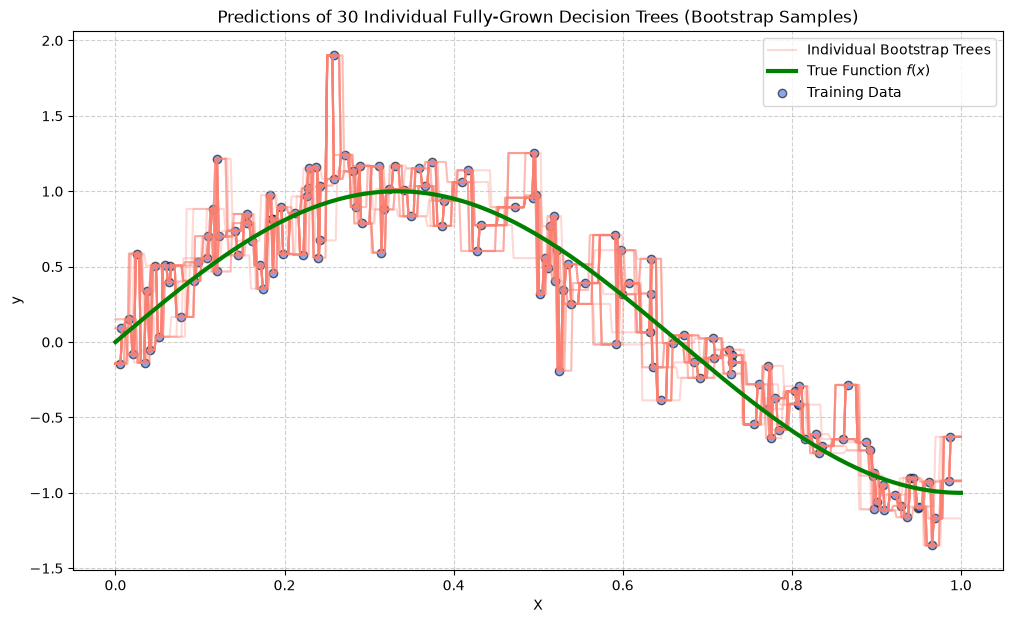

In [6]:
# 11. Train 30 individual, fully-grown Decision Trees, each on a different bootstrap sample of the training data.
# Overlay all 30 predictions on one chart.

n_bootstrap_trees = 30
n_train = len(X_train)
X_grid = np.linspace(0, 1, 500).reshape(-1, 1)

plt.figure(figsize=(12, 7))

# Store predictions to show spread
bootstrap_preds = []

# Set a random seed specifically for bootstrapping to make it reproducible
np.random.seed(100)

for i in range(n_bootstrap_trees):
    # Generate bootstrap sample (with replacement)
    indices = np.random.choice(n_train, size=n_train, replace=True)
    X_bootstrap = X_train[indices]
    y_bootstrap = y_train[indices]
    
    # Train fully-grown tree
    dt_bootstrap = DecisionTreeRegressor(max_depth=None, random_state=i)
    dt_bootstrap.fit(X_bootstrap, y_bootstrap)
    
    # Predict on grid
    y_grid_pred = dt_bootstrap.predict(X_grid)
    bootstrap_preds.append(y_grid_pred)
    
    # Plot curve
    if i == 0:
        plt.plot(X_grid, y_grid_pred, color='salmon', alpha=0.3, label='Individual Bootstrap Trees')
    else:
        plt.plot(X_grid, y_grid_pred, color='salmon', alpha=0.3)

# Plot True Function and Training Points
plt.plot(X_grid, true_function(X_grid), label="True Function $f(x)$", color="green", lw=3)
plt.scatter(X_train, y_train, color="royalblue", alpha=0.6, edgecolors='k', label="Training Data")
plt.title("Predictions of 30 Individual Fully-Grown Decision Trees (Bootstrap Samples)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


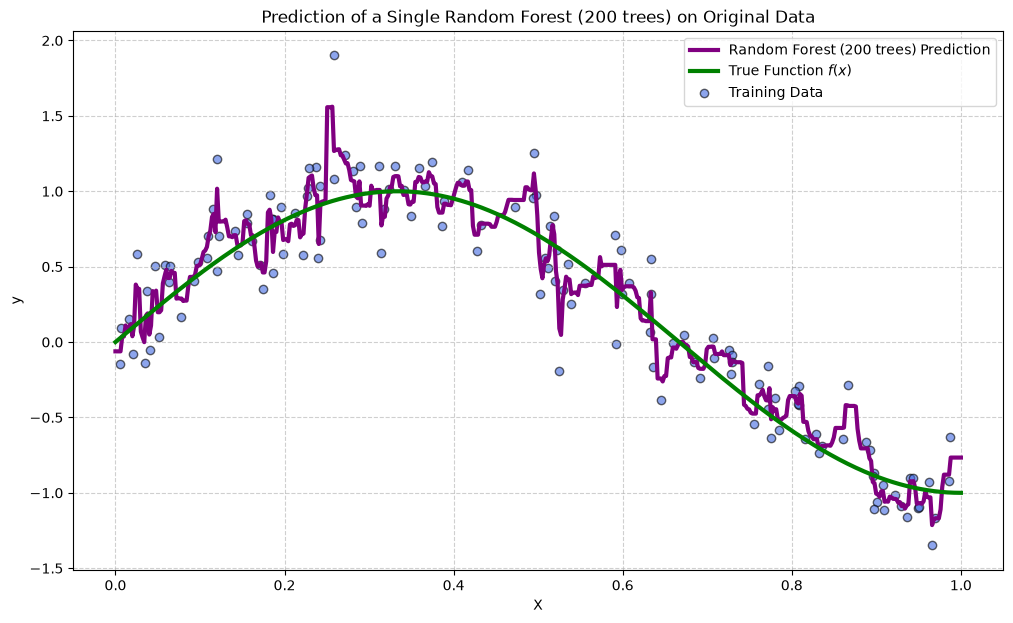

In [7]:
# 12. On a separate chart, plot the prediction of a single Random Forest (200 trees) trained on the original training data.

rf_final = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
rf_final.fit(X_train, y_train)
y_rf_grid_pred = rf_final.predict(X_grid)

plt.figure(figsize=(12, 7))
plt.plot(X_grid, y_rf_grid_pred, color='purple', lw=3, label='Random Forest (200 trees) Prediction')
plt.plot(X_grid, true_function(X_grid), label="True Function $f(x)$", color="green", lw=3)
plt.scatter(X_train, y_train, color="royalblue", alpha=0.6, edgecolors='k', label="Training Data")
plt.title("Prediction of a Single Random Forest (200 trees) on Original Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


### Written Answers (Part C)

#### 13. Compare the two charts: which shows more spread/disagreement (variance)? Which is closer to the true function on average (bias)?
* **Spread/Disagreement (Variance)**: The first chart with the 30 individual trees shows way more spread and disagreement. The lines are extremely jagged, varying wildly from each other as they fit the random noise of their specific bootstrap samples. This represents **high variance**. The second chart showing the Random Forest has a single, smooth line with zero spread or disagreement.
* **Closer to True Function on Average (Bias)**: Both models are built from fully grown decision trees, which are low-bias models. If you averaged the predictions of the 30 individual trees, the mean curve would be very close to the true function, showing low bias on average. However, the Random Forest's single prediction is both close to the true function (low bias) and has zero spread/disagreement, representing extremely low variance.

#### 14. Write one paragraph explaining why Random Forest reduces variance compared to a single Decision Tree, referencing bagging and averaging of largely uncorrelated errors.
A Random Forest reduces variance compared to a single decision tree by using bootstrap aggregation (bagging) to average out prediction errors. Instead of training a single tree on the whole dataset, we train multiple fully-grown trees on different bootstrap samples of the training data. Each tree overfits to its specific sample, but since the samples are different, the errors and noise they capture are largely uncorrelated. When the Random Forest aggregates their predictions by averaging them, the positive and negative errors from different trees tend to cancel each other out. Mathematically, averaging the predictions of $B$ partially correlated trees decreases the ensemble's variance. This averaging process smooths out the high-variance fluctuations of individual trees, resulting in a stable, smooth prediction curve that generalizes much better to unseen test data.


---
<div align="center">

# Assignment Notebook

**Prepared by:** **Aditya Varshney**  
*B.Tech CSE (AIML), GLA University, Mathura*

</div>

---